In [1]:
# Ta komórka ma typ 'Skip' - wykona się, ale nie pojawi się na slajdach
import matplotlib.pyplot as plt
import numpy as np

to sie potem usunie zeby nie wyświetlało się w prezentacji

jupyter nbconvert main.ipynb --to slides --post serve --no-input

jupyter nbconvert main.ipynb --to slides --post serve (to jest wersja do wyświetlania slajdów z kodem)

# Równanie Schrödingera - Analiza Numeryczna
*Julia Zalewska, Oliwia Marut, Natalia Chmiel*

## Wprowadzenie

Równanie Schrödingera jest fundamentalnym równaniem w mechanice kwantowej, opisującym ewolucję funkcji falowej cząstki. Jest to liniowe równanie różniczkowe cząstkowe rzędu pierwszego względem czasu i rzędu drugiego względem przestrzeni. Równanie opisuje, jak stan kwantowy układu zmienia się w czasie, co pozwala na przewidywanie zachowania cząstek na poziomie kwantowym.

## Wyjaśnienie Równania Schrödingera

Równanie Schrödingera opisuje, jak funkcja falowa $\Psi(x,t)$ zmienia się w czasie. Lewa strona równania zawiera pochodną czasową funkcji falowej, co oznacza, że opisuje tempo zmian stanu kwantowego układu. Prawa strona równania zawiera operator Hamiltona $\hat{H}$, który reprezentuje całkowitą energię układu, składającą się z energii kinetycznej (pierwszy składnik) i potencjalnej (drugi składnik). Interpretacja fizyczna równania Schrödingera jest taka, że funkcja falowa $\Psi(x,t)$ zawiera informacje o prawdopodobieństwie znalezienia cząstki w określonym miejscu i czasie. Kwadrat modułu funkcji falowej $|\Psi(x,t)|^2$ daje gęstość prawdopodobieństwa, co pozwala na przewidywanie wyników pomiarów w mechanice kwantowej.

## Model Matematyczny
Równanie Schrödingera dane jest wzorem:

$$i\hbar \frac{\partial}{\partial t} \Psi(x,t) = \left[ -\frac{\hbar^2}{2m} \frac{\partial^2}{\partial x^2} + V(x,t) \right] \Psi(x,t)$$
$$i\hbar \frac{\partial}{\partial t} \Psi(x,t) =  \hat{H} \Psi(x,t)$$

gdzie:
- $i$ to jednostka urojona (dzięki niej rozwiązanie ma charakter falowy),
- $\hbar$ to zredukowana stała Plancka,
- $\Psi(x,t)$ to funkcja falowa,
- $m$ to masa cząstki,
- $V(x,t)$ to potencjał działający na cząstkę,
- $\hat{H}$ to operator Hamiltona, reprezentujący całkowitą energię układu.

## Założenia modelu matematycznego

Zakładamy, że potencjał $V(x,t)$ jest stały w czasie (środowisko jest stacjonarne), czyli $V(x,t) = V(x)$. Dodatkowo, zakładamy, że funkcja falowa $\Psi(x,t)$ może być rozdzielona na część zależną od czasu i część zależną od przestrzeni, czyli $\Psi(x,t) = \Psi(x) \cdot \phi(t)$. 

## Przekształcenie modelu matematycznego

$$i\hbar \frac{\partial}{\partial t} \Psi(x,t) = \left[ -\frac{\hbar^2}{2m} \frac{\partial^2}{\partial x^2} + V(x) \right] \Psi(x,t)$$

$$\iff i\hbar \frac{\partial}{\partial t} [\Psi(x) \cdot \phi(t)] = \left[ -\frac{\hbar^2}{2m} \frac{\partial^2}{\partial x^2} + V(x) \right] [\Psi(x) \cdot \phi(t)]$$

$$\iff i\hbar \cdot \Psi(x) \frac{\partial}{\partial t}\phi(t) = \left[ -\frac{\hbar^2}{2m} \frac{\partial^2 \Psi(x)}{\partial x^2} + V(x)\Psi(x) \right] \phi(t)$$

## Funkcja falowa

W mechanice kwantowej nie znamy dokładnej trajektorii cząstki, dlatego używamy funkcji falowej $\Psi(x,t)$, która zawiera informacje o stanie kwantowym cząstki. Funkcja falowa jest zespolona, a jej moduł kwadratowy $|\Psi(x,t)|^2$ daje gęstość prawdopodobieństwa znalezienia cząstki w określonym miejscu i czasie. Oznacza to, że im większa wartość $|\Psi(x,t)|^2$, tym większe prawdopodobieństwo znalezienia cząstki w danym obszarze przestrzeni. Funkcja falowa zawiera informacje o wszystkich możliwych stanach układu i jest podstawą do obliczania energii czy pędu. 

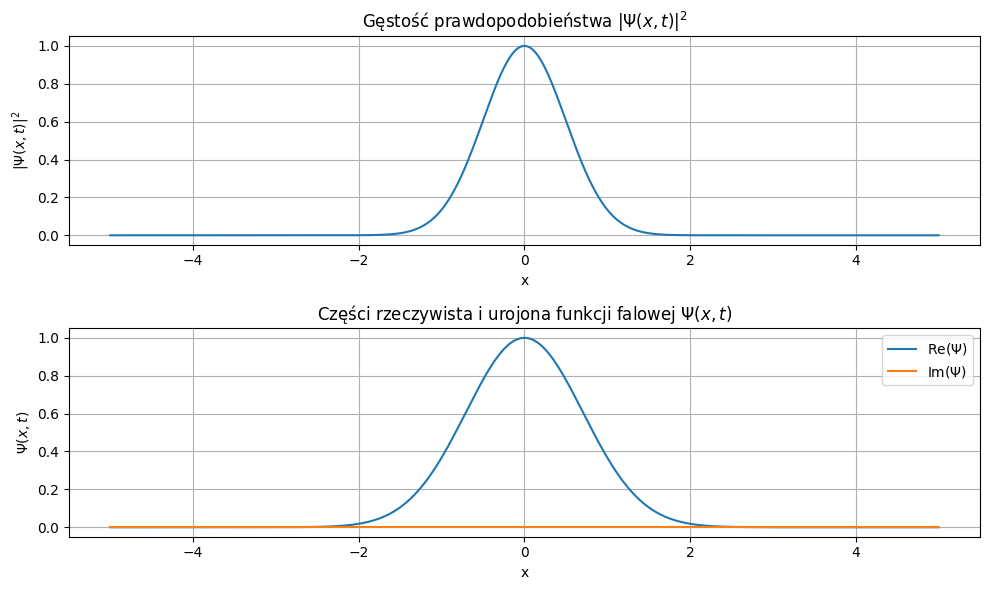

In [2]:
def psi(x, t):
    return np.exp(-x**2)

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

x = np.linspace(-5, 5, 1000)
probability_density = np.abs(psi(x, 0))**2
ax[0].plot(x, probability_density)
ax[0].set_title(r'Gęstość prawdopodobieństwa $|\Psi(x, t)|^2$')
ax[0].set_xlabel('x')   
ax[0].set_ylabel(r'$|\Psi(x, t)|^2$')
ax[0].grid()
ax[1].plot(x, np.real(psi(x, 0)), label=r'Re($\Psi$)')
ax[1].plot(x, np.imag(psi(x, 0)), label=r'Im($\Psi$)')
ax[1].set_title(r'Części rzeczywista i urojona funkcji falowej $\Psi(x, t)$')
ax[1].set_xlabel('x')
ax[1].set_ylabel(r'$\Psi(x, t)$')
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()

Ewolucję jednowymiarowego układu kwantowego opisuje jednorodne równanie różniczkowe cząstkowe rzędu pierwszego względem czasu i rzędu drugiego względem przestrzeni (TDSE):

$$i\hbar \frac{\partial}{\partial t} \Psi(x,t) = \hat{H}\Psi(x,t) = \left[ -\frac{\hbar^2}{2m} \frac{\partial^2}{\partial x^2} + V(x,t) \right] \Psi(x,t)$$

### Rygorystyczne warunki brzegowo-początkowe:
1. **Przynależność do przestrzeni Hilberta ($L^2$):** Funkcja falowa $\Psi(x,t)$ musi być kwadratowo całkowalna, co implikuje warunek normalizacji: $\int_{-\infty}^{+\infty} |\Psi(x,t)|^2 dx = 1$.
2. **Warunek unitarności ewolucji:** Operator ewolucji czasowej $\hat{U}(t) = e^{-i\hat{H}t/\hbar}$ musi być operatorem unitarnym, co gwarantuje zachowanie normy $L^2$ w czasie ($\frac{d}{dt}\|\Psi\|_2 = 0$).
3. **Klasa gładkości:** Dla zapewnienia istnienia pochodnych przestrzennych, stan $\Psi(x,t)$ musi być funkcją klasy $C^2$ względem zmiennej $x$ oraz klasy $C^1$ względem zmiennej $t$.

### Główne założenia:
1. **Normalizowalność:** $\int |\Psi|^2 dx = 1$ (Prawdopodobieństwo musi wynosić 1).
2. **Unitarność:** Ewolucja w czasie musi zachowywać normę.
3. **Ciągłość:** Funkcja falowa i jej pochodna muszą być ciągłe.


## ⚠️ Co może pójść źle? (Aspekty numeryczne)
W fizyce kwantowej błędy numeryczne to nie tylko "niedokładność" – to utrata sensu fizycznego:

*   **Utrata unitarności:** Najczęstszy błąd przy użyciu jawnego schematu Eulera (Explicit Euler). Norma funkcji "wybucha" do nieskończoności.
*   **Dyspersja numeryczna:** Błędne odwzorowanie prędkości grupowych paczki falowej.
*   **Niestabilność Von Neumanna:** Zły dobór kroku czasowego $\Delta t$ względem przestrzennego $\Delta x$.

## 📑 Agenda spotkania
* Punkt pierwszy - wprowadzenie
* Punkt drugi - generowanie wykresu
* Punkt trzeci - podsumowanie

>  **Efekt animacji:** Ta komórka ma typ 'Fragment'. Pojawi się na tym samym slajdzie dopiero po kliknięciu strzałki w prawo!

## 📊 Interaktywne Wykresy
Poniżej znajduje się wykres wygenerowany na żywo za pomocą biblioteki Matplotlib.

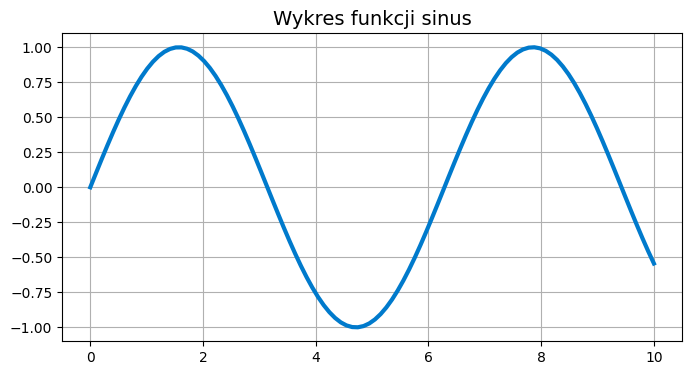

In [3]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, color='#007acc', linewidth=3)
plt.title('Wykres funkcji sinus', fontsize=14)
plt.grid(True)
plt.show()